<a href="https://colab.research.google.com/github/Viggo-Kristensen/mini-gpt/blob/main/transformer_block_experimentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Transformer Block Experimentation**

## **imports**

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt

## **Uploading Data**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 5_blocks.csv to 5_blocks (1).csv


## **Unzipping files**

In [ ]:
import zipfile
import os

zip_filename = list(uploaded.keys())[0]  # gets uploaded zip filename

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall("unzipped_folder")

print(os.listdir("unzipped_folder"))

In [ ]:
block_1 = pd.read_csv("1_block.csv").drop(columns=["Unnamed: 0"])
block_5 = pd.read_csv("5_blocks.csv").drop(columns=["Unnamed: 0"])
block_10 = pd.read_csv("10_blocks.csv").drop(columns=["Unnamed: 0"])

,step,train_loss_list,test_loss_list
0,0,4.668311,4.214245
1,2500,2.230674,2.295919
2,5000,1.916276,2.206855
3,7500,1.810482,1.957713
4,10000,1.755769,2.086890
...,...,...,...
195,487500,1.248467,1.934938
196,490000,1.248604,2.039666
197,492500,1.256232,2.079438
198,495000,1.251218,2.390111


## **Plotting The Data**

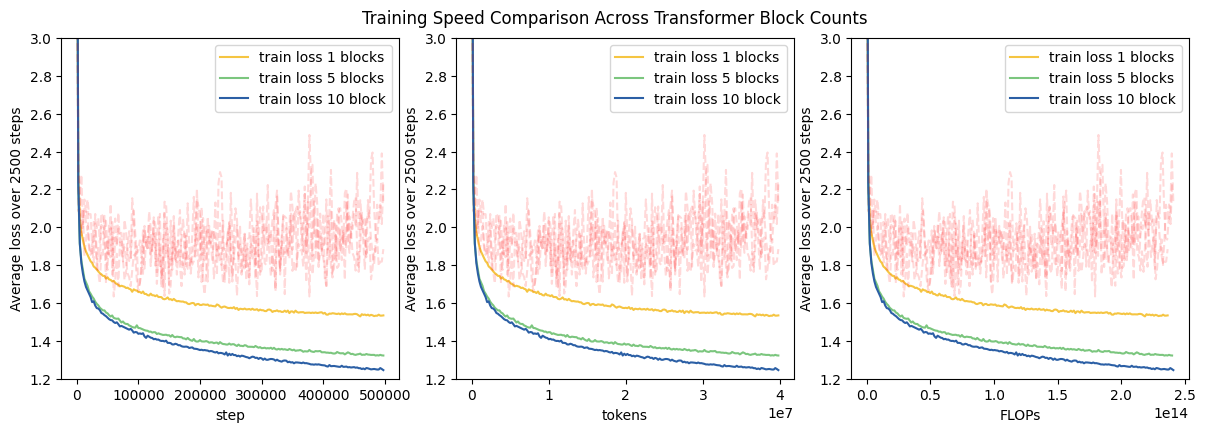

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
plt.tight_layout()

fig.suptitle("Training Speed Comparison Across Transformer Block Counts", y=1.02)

# train and test loss per step
axes[0].plot(block_1["step"], block_1["train_loss_list"], label="train loss 1 blocks", color="#F5C542")
axes[0].plot(block_1["step"], block_1["test_loss_list"], color='red', alpha=0.15, linestyle='--')
axes[0].plot(block_5["step"], block_5["train_loss_list"], label="train loss 5 blocks", color="#7BC67E")
axes[0].plot(block_5["step"], block_5["test_loss_list"], color='red', alpha=0.15, linestyle='--')
axes[0].plot(block_10["step"], block_10["train_loss_list"], label="train loss 10 block", color="#2B5FA5")
axes[0].plot(block_10["step"], block_10["test_loss_list"], color='red', alpha=0.15, linestyle='--')
axes[0].set_xlabel("step")
axes[0].set_ylabel("Average loss over 2500 steps")
axes[0].legend()


# train and test loss per tokens
batch_size = 5
seq_length = 16
block_1["tokens"] = block_1["step"] * batch_size * seq_length
axes[1].plot(block_1["tokens"], block_1["train_loss_list"], label="train loss 1 blocks", color="#F5C542")
axes[1].plot(block_1["tokens"], block_1["test_loss_list"], color='red', alpha=0.15, linestyle='--')
axes[1].plot(block_1["tokens"], block_5["train_loss_list"], label="train loss 5 blocks", color="#7BC67E")
axes[1].plot(block_1["tokens"], block_5["test_loss_list"], color='red', alpha=0.15, linestyle='--')
axes[1].plot(block_1["tokens"], block_10["train_loss_list"], label="train loss 10 block", color="#2B5FA5")
axes[1].plot(block_1["tokens"], block_10["test_loss_list"], color='red', alpha=0.15, linestyle='--')
axes[1].set_xlabel("tokens")
axes[1].set_ylabel("Average loss over 2500 steps")
axes[1].legend()

# train and test loss per FLOPs
block_1["FLOPs"] = block_1["step"] * 4.75e8
block_5["FLOPs"] = block_5["step"] * 4.82e8
block_10["FLOPs"] = block_10["step"] * 4.84e8
axes[2].plot(block_1["FLOPs"], block_1["train_loss_list"], label="train loss 1 blocks", color="#F5C542")
axes[2].plot(block_1["FLOPs"], block_1["test_loss_list"], color='red', alpha=0.15, linestyle='--')
axes[2].plot(block_5["FLOPs"], block_5["train_loss_list"], label="train loss 5 blocks", color="#7BC67E")
axes[2].plot(block_5["FLOPs"], block_5["test_loss_list"], color='red', alpha=0.15, linestyle='--')
axes[2].plot(block_10["FLOPs"], block_10["train_loss_list"], label="train loss 10 block", color="#2B5FA5")
axes[2].plot(block_10["FLOPs"], block_10["test_loss_list"], color='red', alpha=0.15, linestyle='--')
axes[2].set_xlabel("FLOPs")
axes[2].set_ylabel("Average loss over 2500 steps")
axes[2].legend()

for ax in axes:
    ax.set_ylim(1.2, 3.0)

